# RBPF Analysis Notebook

This notebook analyzes the output from the Rao-Blackwellized Particle Filter (RBPF) implementation. It loads data from Parquet files and provides visualizations and metrics for the filtering results.

## Data Files
- `rbpf_output_observations.parquet`: Observation data (timestep, feature indices, observation values)
- `rbpf_output_states.parquet`: Filtered state estimates (weighted means, ESS, max weight)
- `rbpf_output_true_states.parquet`: Ground truth states for comparison

In [1]:
# Import Required Libraries
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Parquet Datasets with Polars

Load the three Parquet files generated by the RBPF simulation and display their schemas.

In [2]:
# Load Parquet Datasets with Polars

# Load observations data
obs_df = pl.read_parquet("rbpf_output_observations.parquet")
print("=== OBSERVATIONS DATA ===")
print(f"Shape: {obs_df.shape}")
print(f"\nSchema:")
print(obs_df.schema)
print(f"\nFirst 5 rows:")
print(obs_df.head())

# Load states data (filtered estimates)
states_df = pl.read_parquet("rbpf_output_states.parquet")
print("\n\n=== STATES DATA ===")
print(f"Shape: {states_df.shape}")
print(f"\nSchema:")
print(states_df.schema)
print(f"\nFirst 5 rows:")
print(states_df.head())

# Load true states data (ground truth)
true_df = pl.read_parquet("rbpf_output_true_states.parquet")
print("\n\n=== TRUE STATES DATA ===")
print(f"Shape: {true_df.shape}")
print(f"\nSchema:")
print(true_df.schema)
print(f"\nFirst 5 rows:")
print(true_df.head())

=== OBSERVATIONS DATA ===
Shape: (200, 5)

Schema:
Schema({'t': Int64, 'x1_index': Int64, 'x2_index': Int64, 'y1_index': Float64, 'y2_index': Float64})

First 5 rows:
shape: (5, 5)
┌─────┬──────────┬──────────┬───────────┬───────────┐
│ t   ┆ x1_index ┆ x2_index ┆ y1_index  ┆ y2_index  │
│ --- ┆ ---      ┆ ---      ┆ ---       ┆ ---       │
│ i64 ┆ i64      ┆ i64      ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════╪═══════════╪═══════════╡
│ 1   ┆ 3        ┆ 5        ┆ -1.630102 ┆ -1.838957 │
│ 2   ┆ 8        ┆ 2        ┆ 3.285406  ┆ -0.475081 │
│ 3   ┆ 4        ┆ 5        ┆ 0.182825  ┆ 1.399799  │
│ 4   ┆ 7        ┆ 8        ┆ 0.960666  ┆ 3.035492  │
│ 5   ┆ 2        ┆ 6        ┆ 1.663484  ┆ 4.653991  │
└─────┴──────────┴──────────┴───────────┴───────────┘


=== STATES DATA ===
Shape: (200, 23)

Schema:
Schema({'timestep': Int64, 'f0_att_mean': Float64, 'f0_def_mean': Float64, 'f1_att_mean': Float64, 'f1_def_mean': Float64, 'f2_att_mean': Float64, 'f2_def_mean': Float64, 'f3_at

## Explore Observations Data

The observations dataframe contains the asynchronous observations at each timestep. Each observation involves two features (x1 and x2) with their corresponding observation values (y1, y2).

In [3]:
# Explore Observations Data

# Display full observations dataframe
print("Observations DataFrame:")
print(obs_df)

# Statistics on observation frequency by feature
print("\n\n=== OBSERVATION FREQUENCY BY FEATURE ===")
# Count how many times each feature appears in observations
x1_counts = obs_df.group_by("x1_index").count().sort("x1_index")
x2_counts = obs_df.group_by("x2_index").count().sort("x2_index")

print("Feature x1 observation counts:")
print(x1_counts)
print("\nFeature x2 observation counts:")
print(x2_counts)

# Most common feature pairings
print("\n\n=== MOST COMMON FEATURE PAIRINGS ===")
pairings = obs_df.group_by(["x1_index", "x2_index"]).count().sort("count", descending=True)
print(pairings.head(10))

Observations DataFrame:
shape: (200, 5)
┌─────┬──────────┬──────────┬───────────┬───────────┐
│ t   ┆ x1_index ┆ x2_index ┆ y1_index  ┆ y2_index  │
│ --- ┆ ---      ┆ ---      ┆ ---       ┆ ---       │
│ i64 ┆ i64      ┆ i64      ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════╪═══════════╪═══════════╡
│ 1   ┆ 3        ┆ 5        ┆ -1.630102 ┆ -1.838957 │
│ 2   ┆ 8        ┆ 2        ┆ 3.285406  ┆ -0.475081 │
│ 3   ┆ 4        ┆ 5        ┆ 0.182825  ┆ 1.399799  │
│ 4   ┆ 7        ┆ 8        ┆ 0.960666  ┆ 3.035492  │
│ 5   ┆ 2        ┆ 6        ┆ 1.663484  ┆ 4.653991  │
│ …   ┆ …        ┆ …        ┆ …         ┆ …         │
│ 196 ┆ 8        ┆ 5        ┆ -4.094404 ┆ -1.260892 │
│ 197 ┆ 1        ┆ 9        ┆ -0.645326 ┆ -4.202994 │
│ 198 ┆ 0        ┆ 2        ┆ -0.586442 ┆ 2.277001  │
│ 199 ┆ 4        ┆ 3        ┆ -1.625462 ┆ -3.003856 │
│ 200 ┆ 3        ┆ 0        ┆ -1.320619 ┆ 1.670345  │
└─────┴──────────┴──────────┴───────────┴───────────┘


=== OBSERVATION FREQUENCY BY FEATURE ===

/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_99745/2334296903.py:10: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  x1_counts = obs_df.group_by("x1_index").count().sort("x1_index")
/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_99745/2334296903.py:11: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  x2_counts = obs_df.group_by("x2_index").count().sort("x2_index")
/var/folders/76/sv22wlqx51l_7wpcjlt9ds2c0000gn/T/ipykernel_99745/2334296903.py:20: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  pairings = obs_df.group_by(["x1_index", "x2_index"]).count().sort("count", descending=True)


## Explore States History Data

The states dataframe contains the filtered state estimates from the RBPF. Each row represents a timestep with weighted mean estimates for each feature's attack and defense values, plus particle filter diagnostics (ESS and max_weight).

In [4]:
# Explore States History Data

# Display states dataframe
print("States DataFrame (Filtered Estimates):")
print(states_df)

# Summary statistics for particle filter diagnostics
print("\n\n=== PARTICLE FILTER DIAGNOSTICS ===")
print("ESS (Effective Sample Size) Statistics:")
ess_stats = states_df.select([
    pl.col("ess").mean().alias("mean"),
    pl.col("ess").std().alias("std"),
    pl.col("ess").min().alias("min"),
    pl.col("ess").max().alias("max"),
])
print(ess_stats)

print("\nMax Weight Statistics:")
weight_stats = states_df.select([
    pl.col("max_weight").mean().alias("mean"),
    pl.col("max_weight").std().alias("std"),
    pl.col("max_weight").min().alias("min"),
    pl.col("max_weight").max().alias("max"),
])
print(weight_stats)

# Show feature estimates for first few timesteps
print("\n\n=== FEATURE ESTIMATES (First 3 timesteps) ===")
feature_cols = [c for c in states_df.columns if c.startswith("f") and c.endswith(("_att_mean", "_def_mean"))]
print(states_df.select(["timestep"] + feature_cols).head(3))

States DataFrame (Filtered Estimates):
shape: (200, 23)
┌──────────┬────────────┬────────────┬────────────┬───┬────────────┬───────────┬───────┬───────────┐
│ timestep ┆ f0_att_mea ┆ f0_def_mea ┆ f1_att_mea ┆ … ┆ f9_att_mea ┆ f9_def_me ┆ ess   ┆ max_weigh │
│ ---      ┆ n          ┆ n          ┆ n          ┆   ┆ n          ┆ an        ┆ ---   ┆ t         │
│ i64      ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---       ┆ f64   ┆ ---       │
│          ┆ f64        ┆ f64        ┆ f64        ┆   ┆ f64        ┆ f64       ┆       ┆ f64       │
╞══════════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════╪═══════════╡
│ 0        ┆ 0.124422   ┆ -0.012842  ┆ 0.191991   ┆ … ┆ -0.021694  ┆ -0.201875 ┆ 100.0 ┆ 0.01      │
│ 1        ┆ 0.044786   ┆ 0.106211   ┆ -0.080971  ┆ … ┆ -0.279641  ┆ -0.222544 ┆ 100.0 ┆ 0.01      │
│ 2        ┆ 0.045714   ┆ 0.078241   ┆ -0.037043  ┆ … ┆ -0.154678  ┆ -0.126116 ┆ 100.0 ┆ 0.01      │
│ 3        ┆ -0.1227    ┆ 0.137231 

## Join and Analyze Combined Data

Join the states (estimates) with true states on timestep to calculate filtering accuracy metrics like RMSE and MAE for each feature.

In [5]:
# Join and Analyze Combined Data

# Join states with true states on timestep
combined_df = states_df.join(true_df, on="timestep", how="inner")

# Calculate errors for each feature
n_features = 10  # D=10
error_metrics = []

for d in range(n_features):
    # Attack errors
    att_est = combined_df[f"f{d}_att_mean"]
    att_true = combined_df[f"f{d}_att_true"]
    att_error = (att_est - att_true).abs()
    att_squared_error = (att_est - att_true) ** 2
    
    # Defense errors
    def_est = combined_df[f"f{d}_def_mean"]
    def_true = combined_df[f"f{d}_def_true"]
    def_error = (def_est - def_true).abs()
    def_squared_error = (def_est - def_true) ** 2
    
    # Combined RMSE and MAE for this feature
    rmse = np.sqrt((att_squared_error.mean() + def_squared_error.mean()) / 2)
    mae = (att_error.mean() + def_error.mean()) / 2
    
    error_metrics.append({
        'feature': d,
        'rmse': rmse,
        'mae': mae
    })

# Create error metrics dataframe
error_df = pl.DataFrame(error_metrics)
print("=== FILTERING ACCURACY BY FEATURE ===")
print(error_df)

print("\n\n=== OVERALL ACCURACY ===")
overall_rmse = error_df['rmse'].mean()
overall_mae = error_df['mae'].mean()
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")

# Show combined dataframe structure
print("\n\n=== COMBINED DATAFRAME (First 3 rows) ===")
print(combined_df.head(3))

=== FILTERING ACCURACY BY FEATURE ===
shape: (10, 3)
┌─────────┬──────────┬──────────┐
│ feature ┆ rmse     ┆ mae      │
│ ---     ┆ ---      ┆ ---      │
│ i64     ┆ f64      ┆ f64      │
╞═════════╪══════════╪══════════╡
│ 0       ┆ 1.297986 ┆ 1.036322 │
│ 1       ┆ 1.320417 ┆ 1.048836 │
│ 2       ┆ 1.222276 ┆ 0.958551 │
│ 3       ┆ 1.448428 ┆ 1.170314 │
│ 4       ┆ 1.253214 ┆ 1.006473 │
│ 5       ┆ 1.286692 ┆ 1.041529 │
│ 6       ┆ 1.355696 ┆ 1.048893 │
│ 7       ┆ 1.334261 ┆ 1.062368 │
│ 8       ┆ 1.357867 ┆ 1.069167 │
│ 9       ┆ 1.217793 ┆ 0.955831 │
└─────────┴──────────┴──────────┘


=== OVERALL ACCURACY ===
Overall RMSE: 1.3095
Overall MAE: 1.0398


=== COMBINED DATAFRAME (First 3 rows) ===
shape: (3, 43)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ timestep ┆ f0_att_me ┆ f0_def_me ┆ f1_att_me ┆ … ┆ f8_att_tr ┆ f8_def_tr ┆ f9_att_tr ┆ f9_def_tr │
│ ---      ┆ an        ┆ an        ┆ an        ┆   ┆ ue        ┆ ue       

## Visualize Filtering Results

Create plots showing:
1. ESS over time (particle diversity)
2. Weight distribution over time
3. Comparison between estimated and true states for selected features

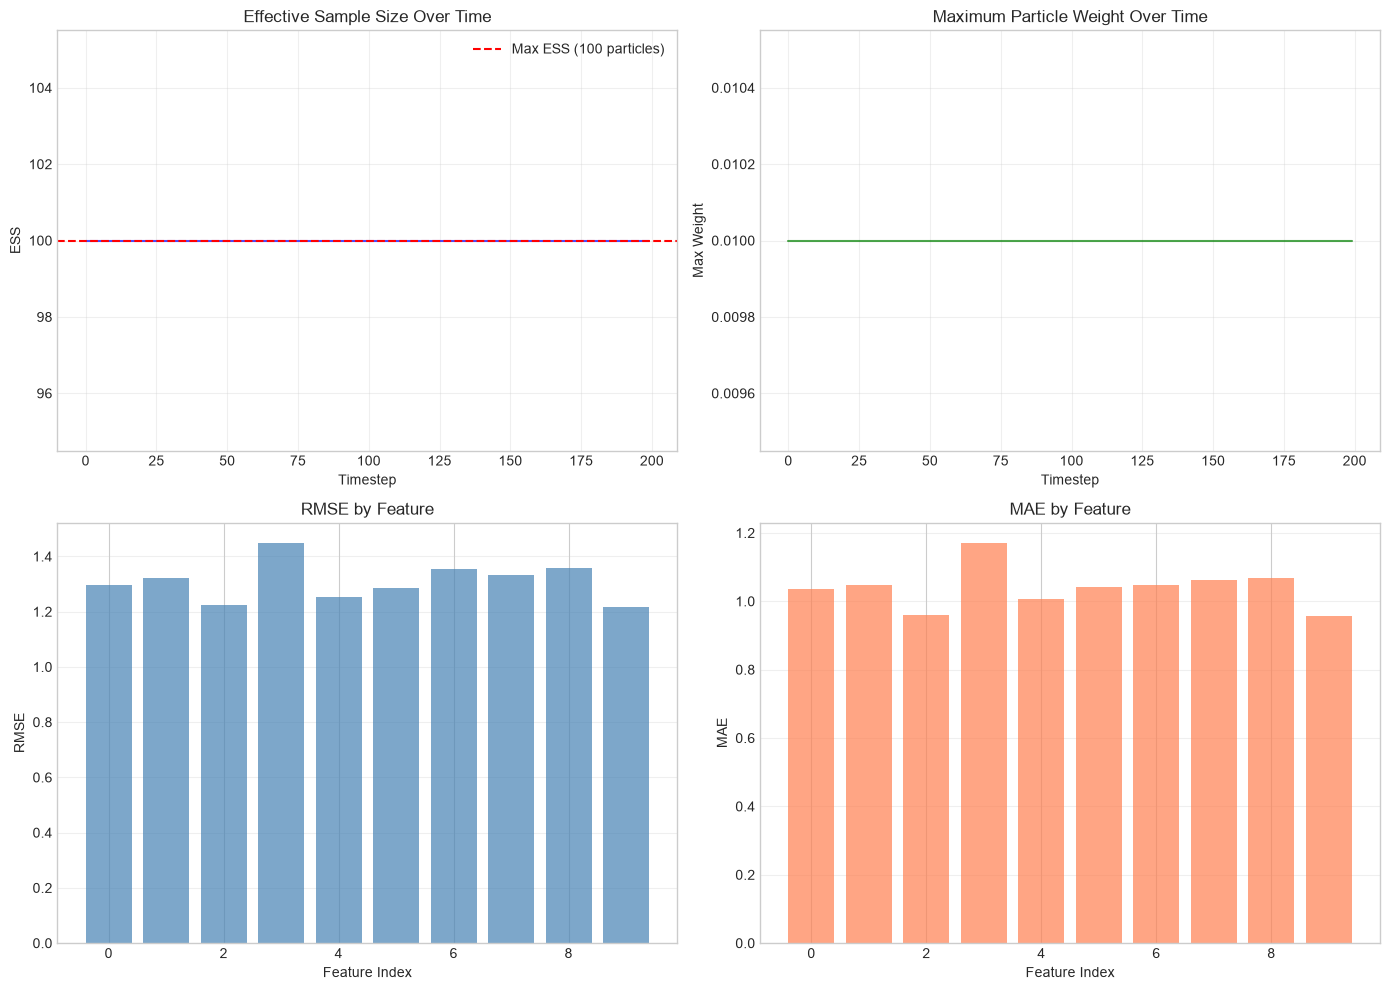


Metrics plot saved to rbpf_metrics.png


In [6]:
# Visualize Filtering Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ESS over time
ax1 = axes[0, 0]
timesteps = states_df['timestep'].to_numpy()
ess_values = states_df['ess'].to_numpy()
ax1.plot(timesteps, ess_values, 'b-', alpha=0.7)
ax1.axhline(y=100, color='r', linestyle='--', label='Max ESS (100 particles)')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('ESS')
ax1.set_title('Effective Sample Size Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Max weight over time
ax2 = axes[0, 1]
max_weights = states_df['max_weight'].to_numpy()
ax2.plot(timesteps, max_weights, 'g-', alpha=0.7)
ax2.set_xlabel('Timestep')
ax2.set_ylabel('Max Weight')
ax2.set_title('Maximum Particle Weight Over Time')
ax2.grid(True, alpha=0.3)

# 3. RMSE by feature
ax3 = axes[1, 0]
features = error_df['feature'].to_numpy()
rmse_values = error_df['rmse'].to_numpy()
ax3.bar(features, rmse_values, color='steelblue', alpha=0.7)
ax3.set_xlabel('Feature Index')
ax3.set_ylabel('RMSE')
ax3.set_title('RMSE by Feature')
ax3.grid(True, alpha=0.3, axis='y')

# 4. MAE by feature
ax4 = axes[1, 1]
mae_values = error_df['mae'].to_numpy()
ax4.bar(features, mae_values, color='coral', alpha=0.7)
ax4.set_xlabel('Feature Index')
ax4.set_ylabel('MAE')
ax4.set_title('MAE by Feature')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rbpf_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nMetrics plot saved to rbpf_metrics.png")

## Trajectory Comparison for Selected Features

Plot the estimated vs true trajectories for a few selected features to visualize the filtering performance.

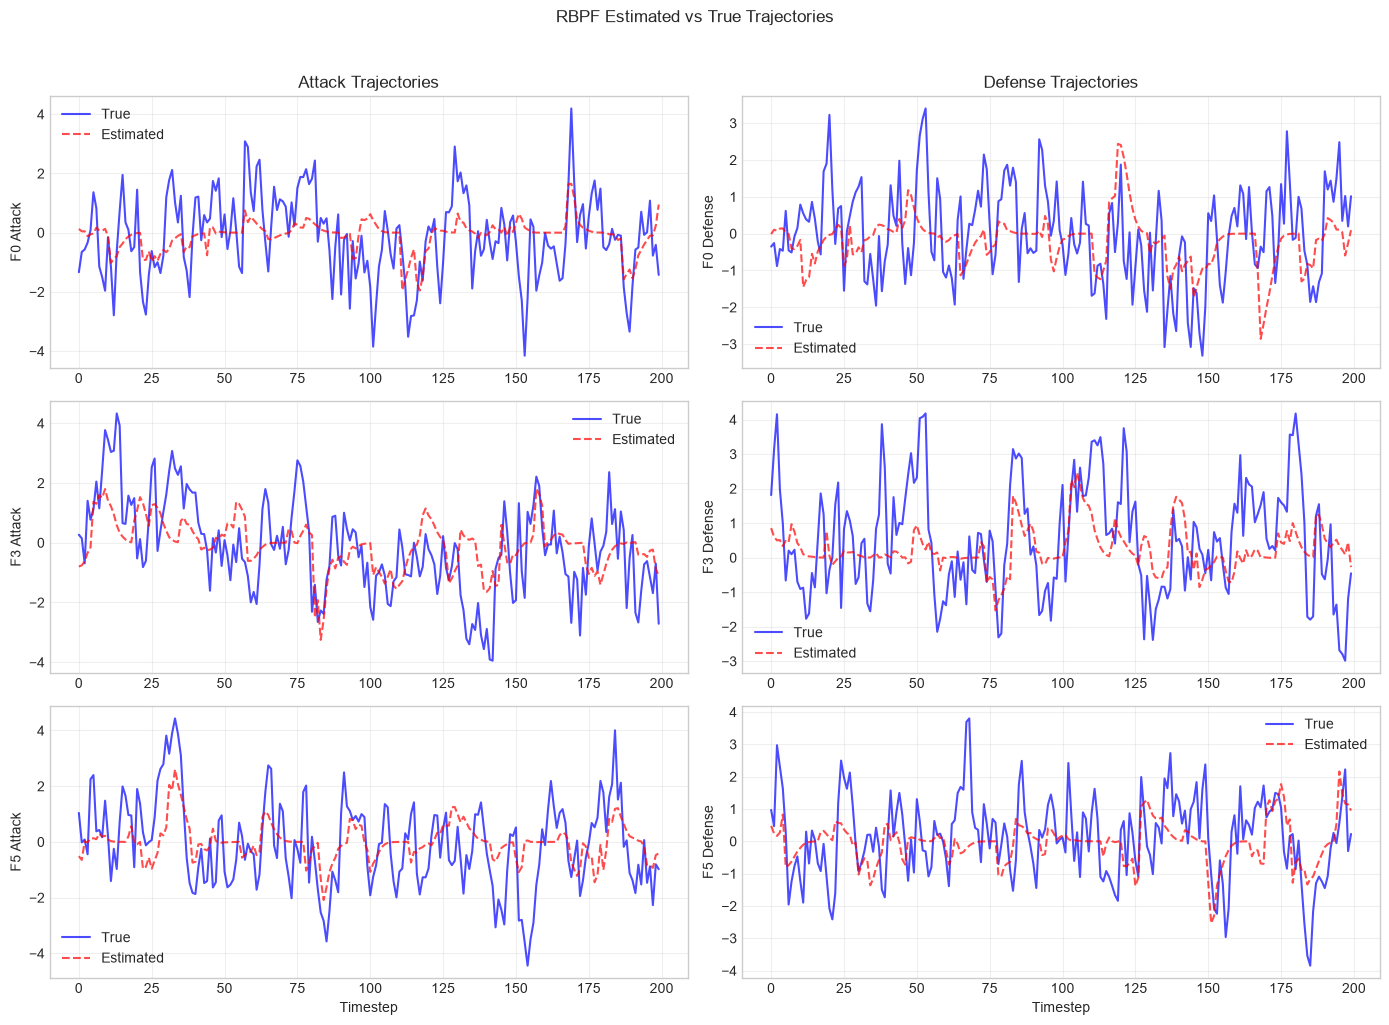


Trajectories plot saved to rbpf_trajectories.png


In [7]:
# Trajectory Comparison for Selected Features

# Select a few features to visualize
selected_features = [0, 3, 5]

fig, axes = plt.subplots(len(selected_features), 2, figsize=(14, 10))

for i, feat_idx in enumerate(selected_features):
    # Attack trajectory
    ax_att = axes[i, 0]
    att_est = combined_df[f"f{feat_idx}_att_mean"].to_numpy()
    att_true = combined_df[f"f{feat_idx}_att_true"].to_numpy()
    ax_att.plot(timesteps, att_true, 'b-', alpha=0.7, label='True')
    ax_att.plot(timesteps, att_est, 'r--', alpha=0.7, label='Estimated')
    ax_att.set_ylabel(f'F{feat_idx} Attack')
    ax_att.legend()
    ax_att.grid(True, alpha=0.3)
    if i == 0:
        ax_att.set_title('Attack Trajectories')
    if i == len(selected_features) - 1:
        ax_att.set_xlabel('Timestep')
    
    # Defense trajectory
    ax_def = axes[i, 1]
    def_est = combined_df[f"f{feat_idx}_def_mean"].to_numpy()
    def_true = combined_df[f"f{feat_idx}_def_true"].to_numpy()
    ax_def.plot(timesteps, def_true, 'b-', alpha=0.7, label='True')
    ax_def.plot(timesteps, def_est, 'r--', alpha=0.7, label='Estimated')
    ax_def.set_ylabel(f'F{feat_idx} Defense')
    ax_def.legend()
    ax_def.grid(True, alpha=0.3)
    if i == 0:
        ax_def.set_title('Defense Trajectories')
    if i == len(selected_features) - 1:
        ax_def.set_xlabel('Timestep')

plt.suptitle('RBPF Estimated vs True Trajectories', y=1.02)
plt.tight_layout()
plt.savefig('rbpf_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTrajectories plot saved to rbpf_trajectories.png")